In [ ]:
#<dTb> = dTb_cap * (1+Eta); Eta= Summ_i,j{r,b,V,U} sigma_i,j
#sigma_i,j=<del_i * del_j>
#save del_U, del_V del_b, del_r : from Ua, Ua_bar, Vk, Vk_bar, rho, rho_bar, xH1_bar

In [5]:
#MODEL fx0.1,10^9 solar mass


import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import gc

#path
new = r'D:\Delta_factors'
path_d = r'E:\CD_data_project'
path_rho = r'E:\density_rho_H_N600'
path_xh1 = r'E:\CD_data_project'

def read_(file):
    f=open(file,'rb')
    n=np.fromfile(f,count=3,dtype='int32')
    d=np.fromfile(f,dtype='float32')
    return d.reshape((600,600,600))

def extract_rho_z():
    pattern = os.path.join(path_rho, "*n_all*.cbin")
    files = sorted(glob.glob(pattern))
    rho_z=[]
    for f in files:
        #extracting z from path
        fname=os.path.basename(f)
        z_=fname.split("n_all")[0]
        rho_z.append(float(z_))
    return np.array(sorted(rho_z))

def nearest_rho_z(z_target, rho_z_array):
    idx = np.argmin(np.abs(rho_z_array - z_target))
    return rho_z_array[idx]
    
def exTractz(fx,mass):    
    pattern = os.path.join(path_xh1, f"*{mass}*{fx}*xhi.cbin")
    files = sorted(glob.glob(pattern))
    redshifts=[]
    for f in files:        
        #extracting z from path
        fname=os.path.basename(f)
        z_=fname.split("zeta")[0]
        z=float(z_)
        redshifts.append(z)
    return sorted(np.array(redshifts))
        

def del_factors(z, fx, mass):
    
    zstr = f"{z:.3f}"
    Tcmb=2.725*(1+z)
    z_rho_match = nearest_rho_z(z, rho_z_array)
    rho_ = glob.glob(os.path.join(path_rho,f"{z_rho_match}*n_all*"))[0]
    rho=read_(rho_)
    xa = read_(glob.glob(os.path.join(path_d,f"{zstr}*_{mass}*_{fx}*lyalpha.cbin"))[0])
    Tk = read_(glob.glob(os.path.join(path_d,f"{zstr}*_{mass}*_{fx}*tk.cbin"))[0])
    
    xh1 = read_(glob.glob(os.path.join(path_xh1,f"{zstr}*_{mass}*_{fx}*xhi.cbin"))[0]) 

    U = xa/(1.0 + xa)
    V = 1.0 - Tcmb/Tk

    #means
    U_bar = np.mean(U)
    V_bar = np.mean(V)
    rho_bar = np.mean(rho)
    xh1_bar = np.mean(xh1)

    #del factors
    del_U = (U/U_bar)-1
    del_V = (V/V_bar)-1
    del_b = (rho/rho_bar)-1
    del_r = (xh1/xh1_bar)-1

    #save
    del_U.astype('float32').tofile(os.path.join(new,
        f"{zstr}_{fx}_{mass}_del_U.bin"))
    del_V.astype('float32').tofile(os.path.join(new,
        f"{zstr}_{fx}_{mass}_del_V.bin"))
    del_b.astype('float32').tofile(os.path.join(new,
        f"{zstr}_{fx}_{mass}_del_b.bin"))
    del_r.astype('float32').tofile(os.path.join(new,
        f"{zstr}_{fx}_{mass}_del_r.bin"))

    del xh1, xa, Tk, rho, U, V
    del del_U, del_V, del_b, del_r
    gc.collect()


In [6]:
fx = "fx0.100E+00"
mass="Mmin0.100E+10"
pattern = os.path.join(path_xh1, f"*{mass}*{fx}*xhi.cbin")

zlist = exTractz(fx,mass)
rho_z_array = extract_rho_z()

for z in zlist:
    del_factors(z,fx,mass)


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import gc

path=r'D:\Delta_factors'      #10.110_fx0.100E+00_Mmin0.100E+10_del_b.bin

def read_(file):
    f=open(file,'rb')
    n=np.fromfile(f,count=3,dtype='int32')
    d=np.fromfile(f,dtype='float32')
    return d.reshape((600,600,600))

    
def read_bin(file):                     #NO HEADER BIN FILES - DEL FACTORS
    with open(file, 'rb') as f:
        data = np.fromfile(f, dtype='float32')
    return data.reshape((600,600,600))

def extractz(fx,mass):    
    pattern = os.path.join(path, f"*{fx}*{mass}*del_U*.bin")
    print (pattern)
    files = sorted(glob.glob(pattern))
    print (files)
    redshifts=[]
    for f in files:        
        #extracting z from path
        fname=os.path.basename(f)
        z_=fname.split("_fx")[0]
        z=float(z_)
        redshifts.append(z)
    print(redshifts)
    return sorted(np.array(redshifts))

def calculate(z, fx, mass):
    zstr = f"{z:.3f}"
    Tcmb=2.725*(1+z)
    del_U=read_bin(glob.glob(os.path.join(path,f"{zstr}*_{fx}*_{mass}*del_U*.bin"))[0])
    del_V=read_bin(glob.glob(os.path.join(path,f"{zstr}*_{fx}*_{mass}*del_V*.bin"))[0])
    del_b=read_bin(glob.glob(os.path.join(path,f"{zstr}*_{fx}*_{mass}*del_b*.bin"))[0])
    del_r=read_bin(glob.glob(os.path.join(path,f"{zstr}*_{fx}*_{mass}*del_r*.bin"))[0])
    Eta=np.mean(del_U*del_V)+np.mean(del_U*del_b)+np.mean(del_U*del_r)+np.mean(del_V*del_b)+np.mean(del_V*del_r)+np.mean(del_b*del_r)
    print(del_U, del_V, del_b, del_r)
    del del_U, del_V, del_b, del_r
    gc.collect()
    return Eta
    
fx = "fx0.100E+00"
mass="Mmin0.100E+10"
z = extractz(fx,mass)
E=[]
for z0 in z:
    eta_val=calculate(z0,fx,mass)
    E.append(eta_val)
print (E,z)

D:\Delta_factors\*fx0.100E+00*Mmin0.100E+10*del_U*.bin
['D:\\Delta_factors\\10.110_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\10.290_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\10.478_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\10.673_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\10.877_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\11.313_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\11.546_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\11.791_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\12.048_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\12.318_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\12.603_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\12.903_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\13.221_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\13.557_fx0.100E+00_Mmin0.100E+10_del_U.bin', 'D:\\Delta_factors\\13.914_fx0.100

In [15]:
path_xh1 = r'E:\CD_data_project'
path_Ts = r'E:\T_spin_cubes'
path_delta = r'E:\1+delta_files'
path_d = r'E:\CD_data_project'

omegab=0.045
omegam=0.31
h=0.68

#def read_(file):
 #   with open(file,'rb') as f:
  #      n=np.fromfile(f,count=3,dtype='int32')
   #     d=np.fromfile(f,dtype='float32')
    #return d.reshape((600,600,600))

#def read_0(file):
 #   with open(file,'rb') as f:
  #      d=np.fromfile(f,dtype='float32')
   # return d.reshape((600,600,600))


def T0(z):
    return (27*(omegab*h**2/0.023)*np.sqrt(0.15/(omegam*h**2))*np.sqrt((1+z)/10))

    
#def extract_z(pattern):
 #   files=sorted(glob.glob(pattern))
  #  zlist=[]
    #for f in files:
     #   z=float(os.path.basename(f).split("zeta")[0])
      #  zlist.append(z)
    #return sorted(zlist)

def global_sig(model, solar_mass, zlist):

    pattern = os.path.join(path_xh1, f"*_{solar_mass}*_{model}*xhi.cbin")
    #zlist=extractz(model,solar_mass)
    mean_dTb=[]
    cap_dTb=[]
    
    for z in zlist:
        zstr=f"{z:.3f}"
        Tcmb=2.725*(1+z)
        
        Ts=read_(glob.glob(os.path.join(path_Ts,f"{zstr}_{solar_mass}_{model}_tspin.cbin"))[0])
        xH1=read_(glob.glob(os.path.join(path_xh1,f"{zstr}*_{solar_mass}*_{model}*xhi.cbin"))[0])
        xa=read_(glob.glob(os.path.join(path_d,f"{zstr}*_{solar_mass}*_{model}*lyalpha.cbin"))[0])
        Tk=read_(glob.glob(os.path.join(path_d,f"{zstr}*_{solar_mass}*_{model}*tk.cbin"))[0])
        delta_term=read_bin(glob.glob(os.path.join(path_delta,f"{zstr}_1+delta_.bin"))[0])

        
        dTb=(26.25*xH1*delta_term*(1-Tcmb/Ts)*np.sqrt((1+z)/10*(0.15/(omegam*h**2)))*(omegab*h**2/0.023))
        mean_dTb.append(np.mean(dTb))


        xh1_bar=np.mean(xH1)
        U_bar=np.mean(xa/(1.0+xa))
        V_bar=np.mean(1.0-Tcmb/Tk)

        dTb_cap=(T0(z)*xh1_bar*U_bar*V_bar)
        cap_dTb.append(dTb_cap)

        del xH1,Ts,xa,Tk,delta_term,dTb
        gc.collect()
        
    return np.array(zlist),np.array(mean_dTb),np.array(cap_dTb)
#np.array(zlist),

z1,Tb_mean,Tb_cap=global_sig(fx, mass, z)
avgTb = Tb_cap*(1+np.array(E))

print(E,  avgTb, Tb_mean, Tb_cap)

[np.float32(0.011479735), np.float32(0.006866481), np.float32(0.0014198236), np.float32(-0.00013617054), np.float32(-0.003156133), np.float32(-0.0044899825), np.float32(-0.0037650662), np.float32(-0.0043253778), np.float32(-0.0035692845), np.float32(-0.0034934552), np.float32(-0.0026419628), np.float32(-0.0023758223), np.float32(-0.0016888238), np.float32(-0.0014288018), np.float32(-0.0008891197), np.float32(-0.0005194107), np.float32(-0.00016175234), np.float32(0.00020220573), np.float32(0.00063482684), np.float32(0.0011712562), np.float32(0.0018459319), np.float32(0.0025803417), np.float32(0.0032414654)] [-210.52116068 -218.81272897 -225.36517751 -231.50365136 -235.73584091
 -241.22065414 -242.59102856 -242.82803273 -242.66310423 -241.53660993
 -239.91245432 -237.40219379 -234.12968805 -229.79579813 -224.20664828
 -216.73100826 -206.51924639 -191.80701066 -170.41717802 -140.23412857
 -101.40813864  -61.05877918  -29.66604789] [-213.36023314 -220.54307652 -226.47659866 -231.33964127 -

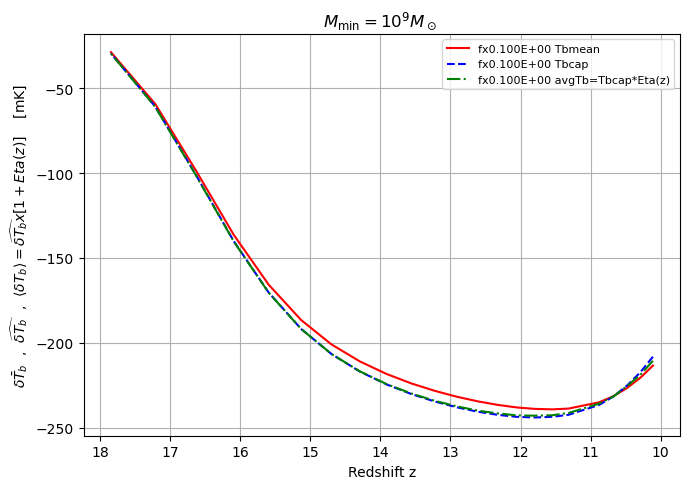

In [24]:
plt.figure(figsize=(7,5))
plt.plot(z,Tb_mean,'-', color='red',label=f'{fx} Tbmean')
plt.plot(z,Tb_cap,'--', color='blue',label=f'{fx} Tbcap')
plt.plot(z,avgTb,'-.',color='green',label=f'{fx} avgTb=Tbcap*Eta(z)')
plt.gca().invert_xaxis()
plt.xlabel('Redshift z')
plt.ylabel(r'$\bar{\delta T_b}$  ,  $\widehat{\delta T_b}$  ,  $\langle \delta T_b \rangle = \widehat{\delta T_b}x[1+Eta(z)]$    [mK]')
plt.title(rf'$M_{{\min}}=10^{9} M_\odot$ ')
plt.legend(fontsize=8)
plt.tight_layout()
plt.grid(True)
plt.show()

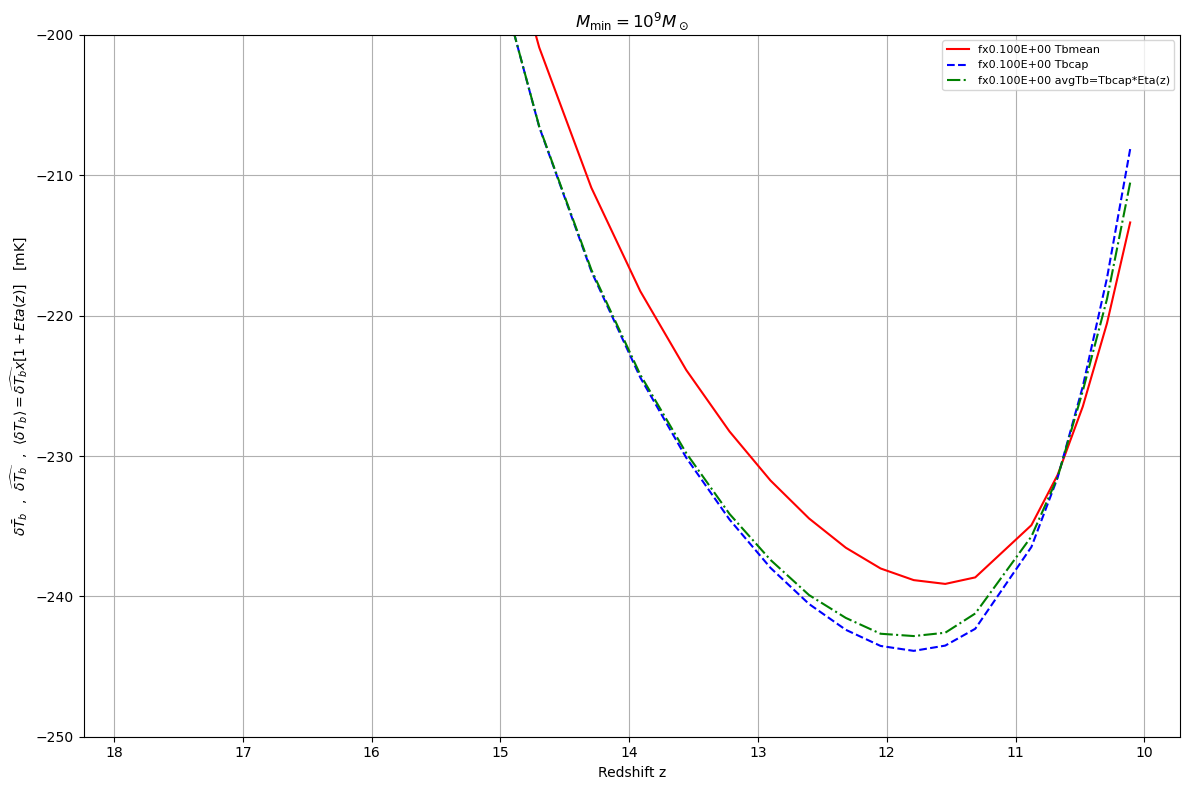

In [26]:
fig,ax=plt.subplots(figsize=(12,8))
ax.plot(z,Tb_mean,'-', color='red',label=f'{fx} Tbmean')
ax.plot(z,Tb_cap,'--', color='blue',label=f'{fx} Tbcap')
ax.plot(z,avgTb,'-.',color='green',label=f'{fx} avgTb=Tbcap*Eta(z)')
ax.invert_xaxis()
ax.set_xlabel('Redshift z')
#ax.set_xlim(0,15) #CLOSE-UP
ax.set_ylabel(r'$\bar{\delta T_b}$  ,  $\widehat{\delta T_b}$  ,  $\langle \delta T_b \rangle = \widehat{\delta T_b}x[1+Eta(z)]$   [mK]')
ax.set_ylim(-250,-200) #CLOSE-UP
ax.set_title(rf'$M_{{\min}}=10^{9} M_\odot$')
ax.legend(fontsize=8)
fig.tight_layout()
ax.grid(True)
plt.show()

In [6]:
##########################################TEST PROGRAM FOR FILE CORRUPTION###############################


import numpy as np

# change these to one actual file each
rho_file = r'E:\density_rho_H_N600\9.938n_all.cbin'
delU_file = r'D:\Delta_factors\10.110_fx0.100E+00_Mmin0.100E+10_del_U.bin'


# ---- Read rho file ----
with open(rho_file, 'rb') as f:
    header = np.fromfile(f, count=3, dtype='int32')
    rho = np.fromfile(f, dtype='float32')

rho = rho.reshape((600,600,600))
print("Rho read successfully")
print("Shape:", rho.shape)
print("Mean:", np.mean(rho))


# ---- Read del_U file ----
with open(delU_file, 'rb') as f:
    header = np.fromfile(f, count=3, dtype='int32')
    delU = np.fromfile(f, dtype='float32')

delU = delU.reshape((600,600,600))
print("\ndel_U read successfully")
print("Shape:", delU.shape)
print("Mean:", np.mean(delU))

Rho read successfully
Shape: (600, 600, 600)
Mean: 11883.513


ValueError: cannot reshape array of size 215999997 into shape (600,600,600)